<a href="https://colab.research.google.com/github/iamMosab21/First__NN/blob/main/First_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

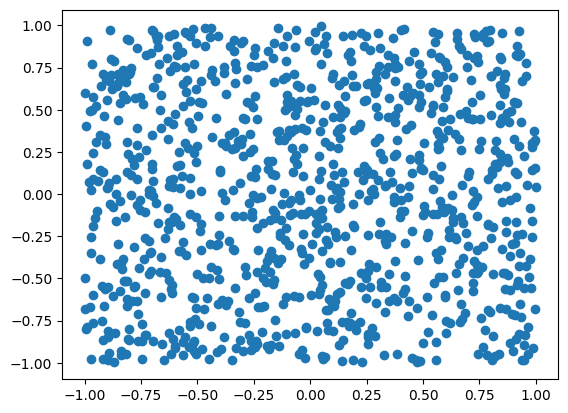

In [ ]:
X = torch.rand(1000, 2) * 2 - 1
plot = plt.scatter(X[:, 0], X[:, 1])
plt.show()


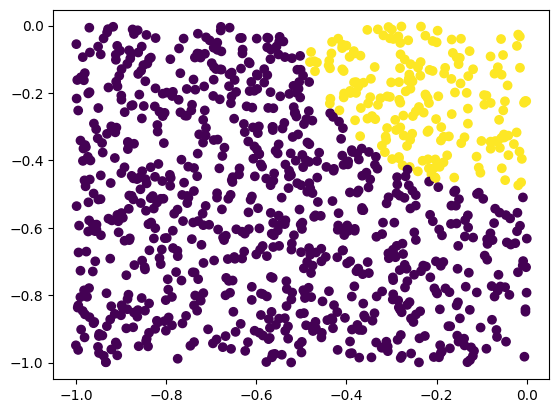

In [ ]:
y = (X[:, 0] ** 2 + X[:, 1] ** 2 < 0.5 ** 2).float()
plot = plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [ ]:
model = nn.Sequential(
    nn.Linear(2, 50),
    nn.ReLU(),
    nn.Linear(50, 1),
    nn.Sigmoid()
)

In [ ]:
loss_function = nn.BCELoss()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
for epoch in range(1000):

    prediction = model(X)

    loss = loss_function(prediction.squeeze(), y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
        print(epoch, loss.item())

In [ ]:
with torch.no_grad():
    prediction = model(X).squeeze()
    predicted = (prediction > 0.5).float()

accuracy = (predicted == y).float().mean()

print("Accuracy:", accuracy.item())

Accuracy: 0.9990000128746033


Test accuracy: 0.9869999885559082


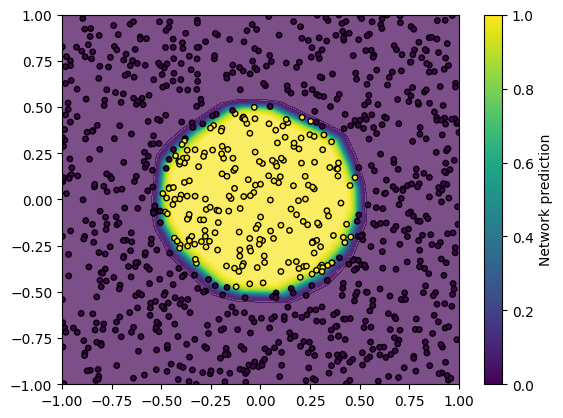

In [ ]:
# Test data
X_test = torch.rand(1000, 2) * 2 - 1
y_test = (X_test[:, 0] ** 2 + X_test[:, 1] ** 2 < 0.5 ** 2).float()

# Test the model
with torch.no_grad():
    prediction = model(X_test).squeeze()
    predicted = (prediction > 0.5).float()

accuracy = (predicted == y_test).float().mean()

print("Test accuracy:", accuracy.item())

# Create a grid
x = torch.linspace(-1, 1, 300)
y = torch.linspace(-1, 1, 300)

xx, yy = torch.meshgrid(x, y, indexing="xy")

grid = torch.stack([
    xx.flatten(),
    yy.flatten()
], dim=1)

# Ask the network to classify every point
with torch.no_grad():
    predictions = model(grid).squeeze()

predictions = predictions.reshape(xx.shape)

# Draw the learned decision boundary
plt.contourf(
    xx.numpy(),
    yy.numpy(),
    predictions.numpy(),
    levels=50,
    alpha=0.7
)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    edgecolors="black",
    s=15
)

plt.colorbar(label="Network prediction")
plt.show()

In [ ]:
torch.save(model.state_dict(), "circle_model.pth")